In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

vendas = pd.read_excel('Base-Dados-Desafio-D&A-01.xlsx', sheet_name='VENDAS')
produtos = pd.read_excel('Base-Dados-Desafio-D&A-01.xlsx', sheet_name='PRODUTOS')

dados = pd.merge(vendas, produtos, on='PRODUTO', how='left')

display(dados)

,CLIENTE,IDADE,ESTADO,PRODUTO,QUANTIDADE_VENDIDA,DATA,CATEGORIA
0,1,47,SANTA CATARINA,A,64,2021-01-05,MAQUINA DE CORTAR GRAMA
1,1,47,SANTA CATARINA,B,488,2021-01-15,MANGUEIRAS
2,1,47,SANTA CATARINA,C,420,2021-01-25,UTILIDADES DOMÉSTICAS
3,1,47,SANTA CATARINA,D,259,2021-02-04,LIMPEZA
4,1,47,SANTA CATARINA,E,387,2021-02-14,JARDINAGEM
5,2,61,SÃO PAULO,A,302,2021-02-24,MAQUINA DE CORTAR GRAMA
6,2,61,SÃO PAULO,B,117,2021-03-06,MANGUEIRAS
7,2,61,SÃO PAULO,C,344,2021-03-16,UTILIDADES DOMÉSTICAS
8,2,61,SÃO PAULO,D,292,2021-04-15,LIMPEZA
9,2,61,SÃO PAULO,E,447,2021-04-25,JARDINAGEM


Perfil demográfico:


,clientes,idade_media,compras
ESTADO,,,
PARAÍBA,2,45.000000,8
SANTA CATARINA,2,45.857143,7
BAHIA,1,26.000000,5
SÃO PAULO,1,61.000000,5
RIO GRANDE DO SUL,1,20.000000,5
RIO DE JANEIRO,1,58.000000,4
PARANÁ,1,43.000000,2


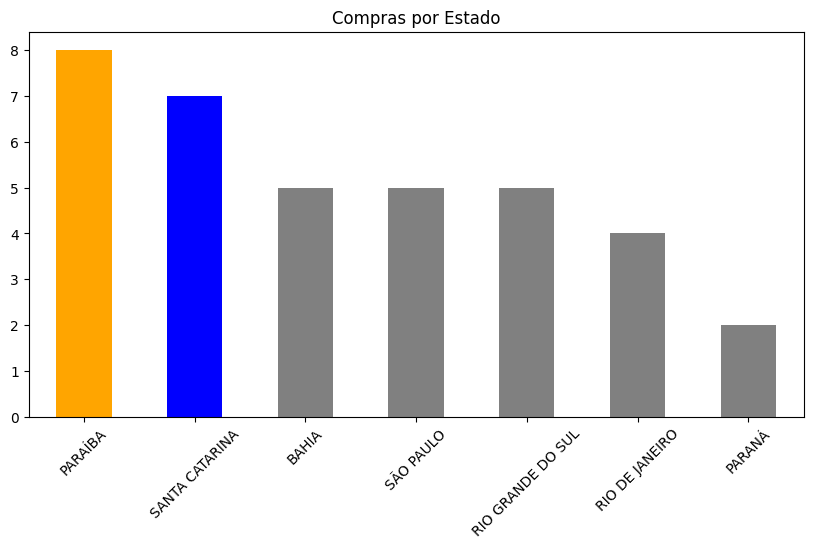

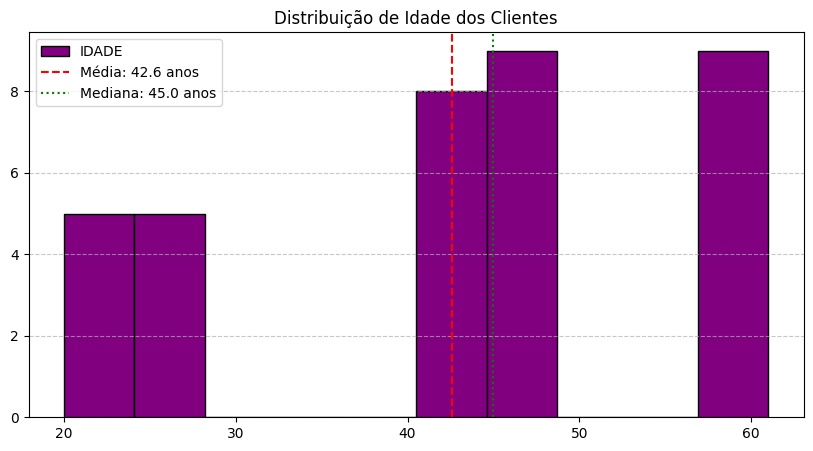

In [23]:
# 1. Qual é o perfil demográfico dos clientes da empresa XYZ?
# Análise
perfil = dados.groupby('ESTADO').agg(
    clientes=('CLIENTE', pd.Series.nunique),
    idade_media=('IDADE', 'mean'),
    compras=('QUANTIDADE_VENDIDA', 'count')
).sort_values('compras', ascending=False)

print("Perfil demográfico:")
display(perfil)

# Gráfico 1: Compras por Estado
perfil['compras'].plot(kind='bar', 
                      title='Compras por Estado',
                      ylabel='',
                      xlabel='',
                      figsize=(10, 5),
                      color=['orange' if estado == 'PARAÍBA' else 'blue' if estado == 'SANTA CATARINA' else 'gray' 
                            for estado in perfil.index])
plt.xticks(rotation=45)
plt.show()

# Gráfico 2: Distribuição de Idade
plt.figure(figsize=(10, 5))

# Histograma
dados['IDADE'].plot(kind='hist',
                   bins=10,
                   color='purple',
                   edgecolor='black')

# Configurações do gráfico
plt.title('Distribuição de Idade dos Clientes')
plt.xlabel('')
plt.ylabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Linhas de média e mediana
media = dados['IDADE'].mean()
mediana = dados['IDADE'].median()
plt.axvline(media, color='red', linestyle='--', label=f'Média: {media:.1f} anos')
plt.axvline(mediana, color='green', linestyle=':', label=f'Mediana: {mediana:.1f} anos')

plt.legend()
plt.show()

In [ ]:
# Conclusões das análises
# A idade dos clientes varia de 20 a 61 anos, com média de 43 anos;
# Paraíba e Santa Catarina são os estados com maior número de compras;
# A distribuição de idade mostra concentração entre 40-49 anos;
# Baixa participação de jovens abaixo de 30 anos.

# Opinião pessoal:
    # Investigar por que os estados não-líderes compram menos (ex.: campanhas de marketing locais, facilidade de entrega dos produtos para estes estados, etc);
    # Desenvolver estratégias para atrair jovens (ex.: produtos com preços acessíveis, divulgação em redes sociais);
    # Manter foco no público principal, oferecendo benefícios como fidelidade.


Categorias por desempenho:


,total_vendido,transacoes,media_por_venda
CATEGORIA,,,
UTILIDADES DOMÉSTICAS,2372,8,296.500000
LIMPEZA,2119,8,264.875000
MAQUINA DE CORTAR GRAMA,1850,7,264.285714
MANGUEIRAS,1844,7,263.428571
JARDINAGEM,1533,6,255.500000


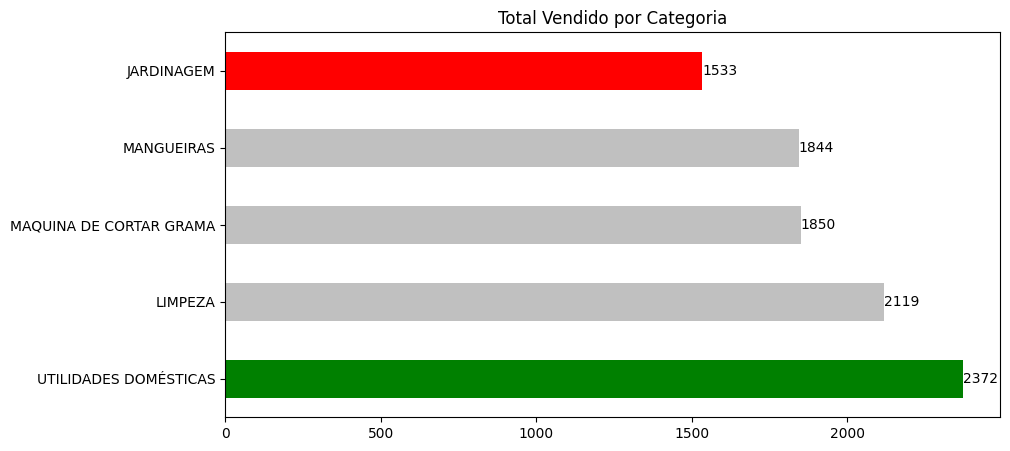

In [25]:
# 2. Qual a categoria de produto mais vendidas e a menos vendidas?
# Análise
categorias = dados.groupby('CATEGORIA')['QUANTIDADE_VENDIDA'].agg(
    ['sum', 'count', 'mean']
).rename(columns={
    'sum': 'total_vendido',
    'count': 'transacoes',
    'mean': 'media_por_venda'
}).sort_values('total_vendido', ascending=False)

print("\nCategorias por desempenho:")
display(categorias)

# Gráfico de Compras
ax = categorias['total_vendido'].plot(
    kind='barh',
    title='Total Vendido por Categoria',
    ylabel='',
    xlabel='',
    figsize=(10, 5),
    color=['green' if cat == categorias.index[0] else 'red' if cat == categorias.index[-1] else 'silver' 
           for cat in categorias.index]
)
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.show()


In [ ]:
# Conclusões das análises:
# A categoria mais vendida é a de Utilidades Domésticas;
# A categoria menos vendida é a de Jardinagem;
# As categorias estão relativamente equilibradas, com todas acima de 1,300 unidades vendidas.

# Opinião pessoal:
    # Criar pacotes promocionais para os produtos das categorias com maiores números de vendas;
    # Investigar se há problemas de disponibilidade, atratividade ou necessidade e associar a produtos complementares (ex.: "Compre uma mangueira + produto de jardinagem com 10% off").


Vendas por mês


MES
1    1742
2    1201
3    1169
4    1252
5    1100
6      51
7     396
8    2000
9     807
Name: QUANTIDADE_VENDIDA, dtype: int64

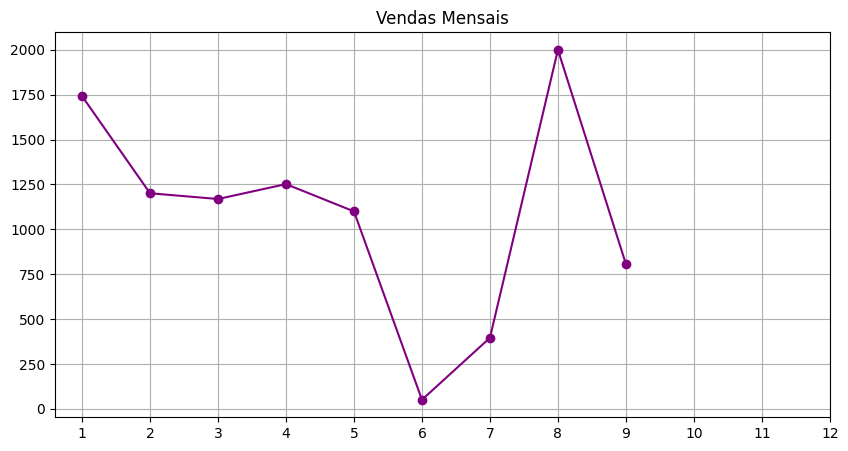

In [35]:
# 3. Há alguma relação entre as vendas e a época do ano?
# Análise
dados['MES'] = pd.to_datetime(dados['DATA']).dt.month
sazonalidade = dados.groupby('MES')['QUANTIDADE_VENDIDA'].sum()

print("\nVendas por mês")
display(sazonalidade)

# Gráfico de Vendas por época
sazonalidade.plot(
    marker='o',
    title='Vendas Mensais',
    ylabel='',
    xlabel='',
    grid=True,
    figsize=(10, 5),
    xticks=range(1, 13),
    color='purple'
)
plt.show()

In [ ]:
# Conclusões das análises:
# Os meses com maior volume de vendas foram janeiro e agosto.
# A maior queda de vendas foi no mês de junho.
# Padrão sazonal não muito definido, mas com picos no início e meio do ano.

# Opinião pessoal:
    # Sim, há relação clara entre vendas e época do ano, visto que:
        # Dois picos anuais (janeiro e agosto), provavelmente por compras motivadas por promoções de início de ano, renovação de estoques domésticos pós-férias e preparação para a primavera (jardinagem, limpeza), campanhas de volta às aulas, respectivamente;
    # Deve-se criar campanhas otimizadas nos períodos de baixa rentabilidade.



Tendência trimestral por região


DATA,2021Q1,2021Q2,2021Q3
ESTADO,,,
BAHIA,0,604,0
PARANÁ,0,0,855
PARAÍBA,1280,766,0
RIO DE JANEIRO,0,294,918
RIO GRANDE DO SUL,451,0,807
SANTA CATARINA,1618,0,623
SÃO PAULO,763,739,0


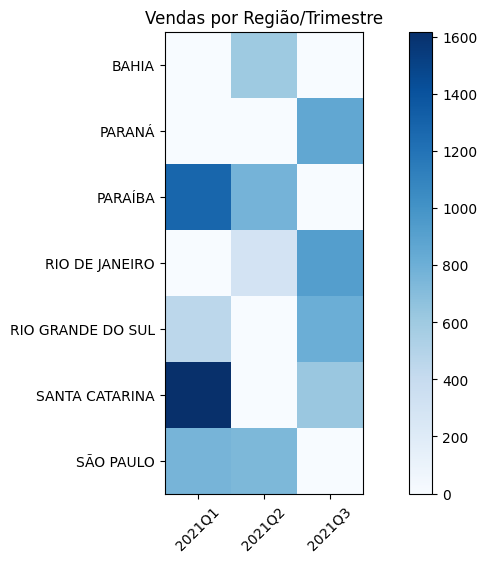

In [38]:
# 4. Qual é a tendência de vendas por região geográfica?
# Análise
tendencia_regiao = dados.pivot_table(
    index='ESTADO',
    columns=pd.to_datetime(dados['DATA']).dt.to_period('Q'),
    values='QUANTIDADE_VENDIDA',
    aggfunc='sum',
    fill_value=0
)

print("\nTendência trimestral por região")
display(tendencia_regiao)

# Mapa de calor
plt.figure(figsize=(12, 6))
plt.imshow(tendencia_regiao, cmap='Blues')
plt.colorbar(label='')
plt.title('Vendas por Região/Trimestre')
plt.xticks(range(len(tendencia_regiao.columns)), tendencia_regiao.columns, rotation=45)
plt.yticks(range(len(tendencia_regiao.index)), tendencia_regiao.index)
plt.show()

In [ ]:
# Conclusões das análises:
# Santa Catarina e Paraíba são os estados com maior volume de vendas;
# O estado da Bahia está exorbitantemente crítico, com o menor índice de vendas em comparação ao resto dos estados;
# Nota-se que no geral, o 2° trimestre apresenta os números mais baixos e similares de venda, em todos os estados.

# Opinião pessoal:
    # Criação de programas de recompensa para clientes frequentes, nos estados da Paraíba e Santa Catarina;
    # Expandir para cidades vizinhas: capitais para o interior;
    # No estado crítico da Bahia, analisar concorrentes dominantes na região e criar medidas de contato com os clientes locais para identificar barreiras (ex.: falta de divulgação, preços não competitivos;
    # Em situações de mitigação sazonal, criar campanhas de promoções estratégicas nos períodos( ex.: Descontos progressivos (ex.: "Compre 3, pague 2").


Relação Idade-Categoria


CATEGORIA,JARDINAGEM,LIMPEZA,MANGUEIRAS,MAQUINA DE CORTAR GRAMA,UTILIDADES DOMÉSTICAS
IDADE,,,,,
"(20, 30]",25,26,403,42,108
"(30, 40]",0,0,0,0,0
"(40, 50]",387,1161,999,1024,1571
"(50, 60]",585,347,0,0,280
"(60, 70]",447,292,117,302,344


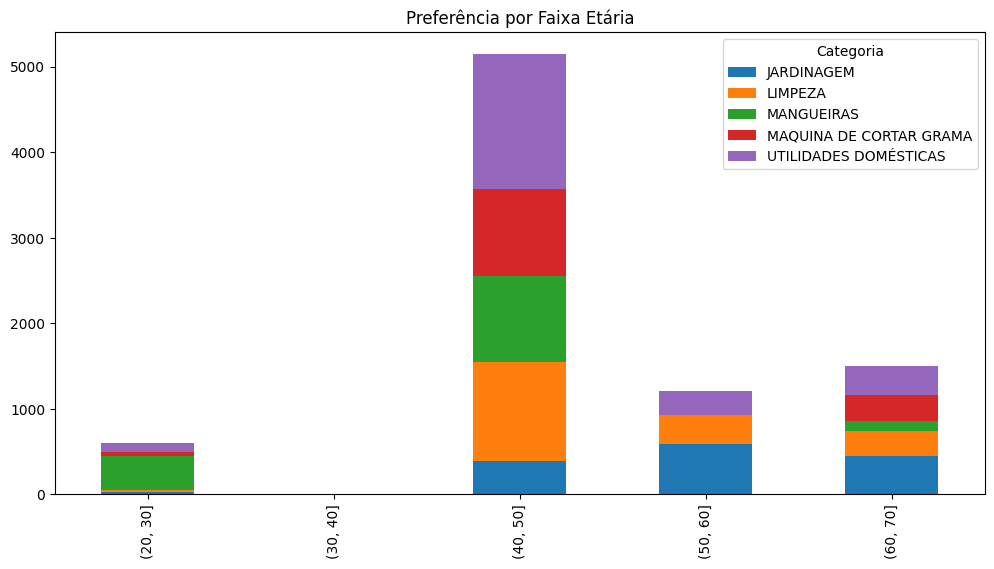

In [39]:
# 5. Há alguma correlação entre a idade dos clientes e as categorias de produtos que eles compram?
# Análise

# Tabela de contingência
correlacao = pd.crosstab(
    index=pd.cut(dados['IDADE'], bins=[20, 30, 40, 50, 60, 70]),
    columns=dados['CATEGORIA'],
    values=dados['QUANTIDADE_VENDIDA'],
    aggfunc='sum'
)

print("\nRelação Idade-Categoria")
display(correlacao)

# Gráfico de calor
correlacao.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Preferência por Faixa Etária')
plt.ylabel('')
plt.xlabel('')
plt.legend(title='Categoria', bbox_to_anchor=(1.00, 1))
plt.show()

In [ ]:
# Conclusões das análises:
# Clientes mais jovens (20-30 anos) compram mais produtos da categoria de Mangueiras;
# Faixa etária de 40-50 anos é a que mais compra produtos de Utilidades Domésticas;
# Utensílios Domésticos têm boa aceitação em todas as faixas etárias.
# Faixa etária de 30-40 anos não realiza compras de nenhuma categoria.

# Opinião pessoal:
    #  Sim, há correlação entre a idade dos clientes e as categorias de produtos que eles compram, visto que:
        # Clientes jovens possuem foco em Mangueiras e Utilidades Domésticas, e baixo interesse em Jardinagem/Limpeza:
            # Mangueiras: uso para lavar carros em casa, atividades recreativas (banho de mangueira no verão); Utensílios Domésticos: primeira casa/apartamento, necessidade de itens básicos; Baixa adesão a Jardinagem/Limpeza: moram em locais com menos espaço (apartamentos) ou terceirizam serviços.
        # Clientes de Meia-Idade têm maior volume geral: Dominam todas as categorias e possuem pico em Utilidades Domésticas e Limpeza:
            # Fase de consolidação: casas maiores, famílias, necessidade de manutenção doméstica; Poder aquisitivo: capacidade de comprar produtos premium (ex.: máquinas de cortar grama); Limpeza: preocupação com higiene em residências com crianças/animais.
        # Clientes 50+ anos possuem a Jardinagem como categoria preferida e abandono progressivo de Mangueiras e Máquinas:
            # Jardinagem: hobby na aposentadoria, mais tempo livre; Redução em Mangueiras/Máquinas: Dificuldade física para manuseio ou preferência por serviços terceirizados.
    # Cabe uma investigação profunda e urgente do fato de clientes de faixa etária 30-40 anos não serem clientes da empresa.

In [ ]:
# Como chegou a suas conclusões e quais são as limitações e implicações de suas análises?
# Utilizei análise exploratória com Python e as bibliotecas Pandas e Matplotlib, cruzando dados de vendas e produtos. 
# Técnicas principais: agregações, análise temporal, tabelas de contingência e visualizações de gráficos me ajudaram a identificar padrões.
# Limitações:
# Falta de registros para clientes de 30-40 anos;
# Variáveis importantes não analisadas e/ou não fornecidos (gênero, canal de venda, margens).
# Implicações Práticas:
# Estoque: Ajustar para picos em janeiro/agosto e quedas em junho;
# Expansão: Investigar baixo desempenho na Bahia e ausência em regiões como Norte.
# Próximos passos viáveis:
# Coletar dados mais recentes e completos;
# Testar ações pontuais (ex.: promoções na Bahia);
# Criar dashboard no Power BI para monitoramento contínuo.